### Projeto

## Modelo de Classificação Para Análise de Sentimentos

**1. Definição do Problema de Negócio**

É a fundamentação do projeto. Nesta etapa, truduzimos uma necessidade da empresa em um objetivo claro para a ciência de dados. Definimos o que queremos resolver (automatizar a classificação de reviews de produtos, por exemplo), porque é importante (reduzir custos, agilizar a tomada de decisão) e como o sucesso será medido.

**Definição**

Uma empresa de e-commerce deseja automatizar a análise de feedbacks de seus clientes. Atualmente, a análise é feita manualmente, o que é um processo lento, caro e que não escala com o volume de reviews revebidos diariamente.

**Objetivo:**

Criar um modelo de machine learning que classifique automaticamente os reviews de produtos como 'positivo' ou 'negativo'.

**Benefícios Esperados:**

 - Eficiência: Reduzir o tempo e o custo da análise de feedback.
 - Tomada de decisão rápida: Permitir que as equipes de produto e marketing identifiquem rapidamente produtos  com problemas ou oportunidades de melhoria.
 - Priorização: Direcionar reviews negativos para a equipe de suporte ao cliente de forma prioritária, melhorando a experiência do consumidor.

 **2. Importação dos Pacotes**

 Esta é a fase de preparação do ambiente de trabalho. Aqui, carregamos todas as ferramentas e bibliotecas Python necessárias ( como Pandas para a manipulação de dados, Scikit-learn para modelagem e Matplotlib/Seaborn para visualização) que serão utilizadas ao longo do projeto.

In [1]:
# Manipulação de Dados e Visualização
import re
import pandas as pd
import numpy as np
import unicodedata
import seaborn as sns
import matplotlib.pyplot as plt

# Pré-Processamento e Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [2]:
# Configuração de Visualização
sns.set_style('whitegrid')
%matplotlib inline

In [3]:
%reload_ext watermark
%watermark -a "Leonardo da Silva Neves"

Author: Leonardo da Silva Neves



In [4]:
%watermark --iversions

joblib    : 1.5.3
matplotlib: 3.10.8
numpy     : 2.3.5
pandas    : 2.3.3
re        : 2.2.1
seaborn   : 0.13.2
sklearn   : 1.8.0



**3. Carregando e Compreendendo os Dados**

É o primeiro contato com matéria-prima do projeto. Lemos os dados de uma fonte (no nosso caso, um arquivo CSV) para um DataFrame do Pandas e realizamos uma verificação inicial para entender sua estrutura.

In [5]:
# Define o nome do arquivo
file = 'dataset.csv'

In [6]:
# Carrega o dataset
df = pd.read_csv(file)

In [7]:
# Shape
df.shape

(500, 3)

In [8]:
# Primeiras Linhas
df.head()

,review_id,texto_review,sentimento
0,1,Estou muito feliz com a compra. O cadeira game...,positivo
1,2,NaN,negativo
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo
3,4,O monitor é decepcionante. O suporte ao client...,positivo
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo


In [9]:
# Amostra dos dados
df.sample(10)

,review_id,texto_review,sentimento
15,16,Ótimo custo-benefício. O fone de ouvido é incr...,positivo
361,362,Estou muito arrependido com esta compra. Dinhe...,negativo
247,248,O celular é exatamente como descrito no anúnci...,negativo
24,25,Ótimo custo-benefício. O mouse é fantástica e ...,positivo
56,57,Recebi o mouse hoje. Vou começar a usar para v...,negativo
381,382,Amei o cadeira gamer! A qualidade é fantástica...,positivo
73,74,Odiei o teclado. Qualidade péssima e veio com ...,negativo
213,214,Ótimo custo-benefício. O notebook é excelente ...,positivo
163,164,Simplesmente perfeito! O monitor funciona muit...,positivo
335,336,Ótimo custo-benefício. O cadeira gamer é ótima...,positivo


In [10]:
# Últimas linhas
df.tail()

,review_id,texto_review,sentimento
495,496,Odiei o teclado. Qualidade de baixa qualidade ...,negativo
496,497,Estou muito impressionado com a compra. O moni...,positivo
497,498,Não recomendo. A entrega demorou uma eternidad...,negativo
498,499,Estou muito arrependido com esta compra. Dinhe...,negativo
499,500,Ótimo custo-benefício. O cadeira gamer é incrí...,positivo


**4. Análise Exploratória de Dados**

A fase de investigação. Aqui, "mergulhamos" nos dados para descobrir padrões, anomalias e insights. Utilizamos gráficos (como a contagem de sentimentos positivos vs. negativos) e estatísticas para entender a distribuição e as características dos dados antes de qualquer modificação.

In [11]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   review_id     500 non-null    int64 
 1   texto_review  488 non-null    object
 2   sentimento    500 non-null    object
dtypes: int64(1), object(2)
memory usage: 11.8+ KB


In [12]:
print("\nVerificando Valores Ausentes:\n")
print(df.isnull().sum())


Verificando Valores Ausentes:

review_id        0
texto_review    12
sentimento       0
dtype: int64



Distribuição dos Sentimentos



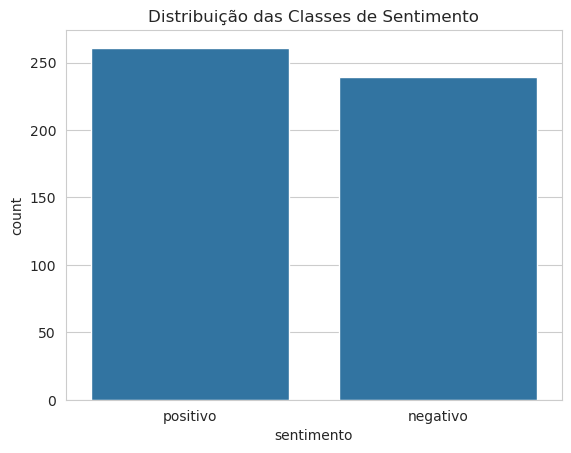

In [13]:
print("\nDistribuição dos Sentimentos\n")
sns.countplot(x = 'sentimento', data = df)
plt.title('Distribuição das Classes de Sentimento')
plt.show()

**5. Limpeza de Dados**

Nesta etapa corrigimos os problemas identificados na EDA. Isso inclui tratar valores ausentes (por exemplo, removendo as linhas correspondentes), garantir que os dados estejam no formato correto e aplicar a função de limpeza de texto (dsa_limpa_texto) para normalizar os reviews, removendo acentos, pontuações e caracteres indesejados.

In [14]:
# Remover linhas com valores ausentes
print(f"\nTamanho original do DataFrame: {len(df)}")
df.dropna(subset = ['texto_review'], inplace = True)
print(f"Tamanho do DataFrame após remoção dos valores nulos: {df.shape[0]}")


Tamanho original do DataFrame: 500
Tamanho do DataFrame após remoção dos valores nulos: 488


In [15]:
df.shape

(488, 3)

In [16]:
df.head()

,review_id,texto_review,sentimento
0,1,Estou muito feliz com a compra. O cadeira game...,positivo
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo
3,4,O monitor é decepcionante. O suporte ao client...,positivo
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo
5,6,Não rceomendo. A entrega atrasou muito e o mon...,positivo


In [17]:
# Função de limpeza de texto
def limpa_texto(texto):

    """
    Função completa de limpeza de texto:
    1. Converte para minúsculo.
    2. Remove acento e cedilha.
    3. Remove pontuação, números e caracteres especiais.
    4. Remove espaços extras.
    """

    # Garante que o texto não seja nulo (caso haja algum NaN no DataFrame)
    if not isinstance(texto, str):
        return ""

    # --- PASSO 1: Normalizar e remover acentos ---
    # Normalizar para a forma 'NFKD' que separa o caracter da acentuação
    # e depois remove os acentos (Nonspacing Mark)
    texto_sem_acentos = ''.join(c for c in unicodedata.normalize('NFKD', texto) if unicodedata.category(c) != 'Mn')

    # PASSO 2: Limpeza com Regex ---
    # Converter para minúsculas
    texto_limpo = texto_sem_acentos.lower()

    # Manter apenas letras e espaços. A remoção de acentos já foi feita.
    texto_limpo = re.sub(r'[^a-z\s]', '', texto_limpo)

    # Remove espaços extras
    texto_limpo = re.sub(r'\s+', ' ', texto_limpo).strip()

    return texto_limpo

In [18]:
# Aplica a função de limpeza
df['texto_limpo'] = df['texto_review'].apply(limpa_texto)

In [19]:
df.head()

,review_id,texto_review,sentimento,texto_limpo
0,1,Estou muito feliz com a compra. O cadeira game...,positivo,estou muito feliz com a compra o cadeira gamer...
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo,nao recomendo a entrega foi lenta e o celular ...
3,4,O monitor é decepcionante. O suporte ao client...,positivo,o monitor e decepcionante o suporte ao cliente...
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo,e um livro ok pelo prceo que paguei
5,6,Não rceomendo. A entrega atrasou muito e o mon...,positivo,nao rceomendo a entrega atrasou muito e o moni...


https://docs.python.org/3/library/re.html

**6. Engenharia de Atributos**

É a etapa onde transformamos dados brutos em  "features" (atributos) úteis para o modelo. No nosso projeto, isso envolveu a criação da coluna texto_limpo e, mais importante, a conversão de classes de texto ('positivo', 'negativo') em um formato numérico (sentimento_label: 1,0), que é o que o algorítmo de machine learning consegue entender.

In [20]:
# Mapear o sentimento para valores numéricos (Engenharia  de Atributos)
df['sentimento_label'] = df['sentimento'].map({'positivo':1, 'negativo': 0})

print("DataFrame após a limpeza e mapeamento:\n")
df[['texto_limpo', 'sentimento_label']].head()

**7. Divisão em Dados de Treino e Teste**

Um passo essencial para treinamento e avaliação do modelo. Separamos o conjunto de dados em duas partes: um maior (treino), que o modelo usará para aprender, e uma menor (teste), que será mantida "escondida" do modelo para simular dados novos e avaliar sua real performance após o treinamento.

In [21]:
# Definir variáveis X (entrada) e y (saída)
X = df['texto_limpo']
y = df['sentimento_label']

In [22]:
# Dividir os dados em treino e teste

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.25, random_state = 42, stratify = y)

**8. Pipeline de Modelagem Preditiva**

Aqui, construimos uma esteira de produção automatizada para o nosso modelo. O pipeline do Scikit-learn encapsula todas as etapas de pré-processamento (vetorização TF-IDF, padronização com StandardScaler) e o modelo final (Regressão Logística), garantindo que os mesmos passos sejam aplicados de forma consistente nos dados de treino e nos novos dados.

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

In [23]:
# Pipeline
pipeline = Pipeline([

    ('tfidf', TfidfVectorizer(stop_words = ['de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um'])),

    ('scaler', StandardScaler(with_mean = False)),

    ('logreg', LogisticRegression(solver = 'liblinear', random_state = 42, max_iter = 1000))

])                         

O pipeline é composto por três etapas sequenciais, cada uma com um nome ('tfidf', 'scaler', 'logreg') e uma função específica.

**8.1. Vetorização dos Dados de Texto ('tfidf', TfidfVectorizer(...))**

O que faz? Esta é a primeira etapa, chamada 'tfidf'. Ela usa o TfidfVectorizer para converter  o texto bruto em números. Ele transforma cada review em um vetor numérico, onde cada número representa a importância de uma palavra naquele texto em relação a todos os outros textos. Palavra comuns como 'de', 'a', 'o', etc., são ignoradas (stop_words).

**8.2. Padronização de Dados ('scaler', StandardScaler(with_mean=False))**

O que faz? A segunda etapa, 'scaler', pega os vetores criados pela etapa anterior e os padroniza. O StandardScaler ajusta a escala de todos os números para que tenham uma variância semelhante. O parâmetro with_mean=False é essencial aqui, pois a matriz de dados do TF-IDF é "espersa" (cheia de zeros), e essa opção preserva essa característica, evitando problemas de memória e computação.

**8.3. Modelo de Machine Learning ('logreg', LogicRegression(...))**

O que faz? A etapa final, 'logreg', é o modelo de classificação em si. A LogicRegression recebe os dados numéricos, já padronizados, e aprende a fazer a previsão final: classificar o texto como 'positivo' ou 'negativo'.

O grande benefício do pipeline é a automaçãoe a consistência. Ao treinar esse pipeline, ele aprende a fazer todas as três coisas. Depois, quando apresentamos um novo texto para ele prever, o pipeline automaticamente executa a mesma sequência exata de vetorização, padronização e classificação, garantindo que não haja erros no pré-processamento.

**8.4. Otimização de Hiperparâmetros**

É o ajuste fino do modelo. Usando GridSearchCV, testemos sistematicamente várias combinações de configurações (hiperparâmetros) para o pipeline, a fim de encontrar a conbinação que resulta na melhor performance possível.

In [24]:
# Definir o grid de hiperparâmetros para otimização
parametros_grid = {
    'tfidf__max_features': [500, 1000, 2000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'logreg__C': [0.1, 1, 10],
    'logreg__l1_ratio': [0,1],
    'logreg__max_iter': [5000, 6000]
}

In [25]:
# Configurar o GridSearchCV
grid_search = GridSearchCV(
    pipeline,   # pipeline com as etapas de pré-processamento e modelo
    parametros_grid,  # Dicionário com as combinações de hiperparâmetros a serem testados
    cv = 5,   # Número de divisão para  validação cruzada (5-fold cross-validation)
    n_jobs = -1,  # Usa todos os núcleos disponíveis do processador para acelerar o processo
    scoring = 'accuracy',  # Métrica usada para avaliar o desempenho de cada combinação (aqui, acurácia)
    verbose = 1  # Nível de detalhamento do output durante a execução (1 exive processo básico)
)

Validação cruzada é uma técnica usada para avaliar o desempenho de um modelo dividindo o conjunto de dados em várias partes (ou "folds"). O modelo é treinado em algumas dessas partes e testado em outras, de forma rotativa. Isso permite mediro desempenho de forma mais confiável e geral, evitando que o resultado dependa apenas de uma única divisão dos dados.

**8.5. Treinamento do Modelo**

Nesta etapa, alimentamos o pipeline com os dados de treino. O GridSearchCV executa o processo de .fit(), onde o algorítimo aprende os padrões que conectam o texto dos reviews aos seus respectivos sentimentos.

In [26]:
print("\nIniciando o treinamento do modelo com otimização de hiperparâmetros...\n")
grid_search.fit(X_treino, y_treino)


Iniciando o treinamento do modelo com otimização de hiperparâmetros...

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logreg__C': [0.1, 1, ...], 'logreg__l1_ratio': [0, 1], 'logreg__max_iter': [5000, 6000], 'tfidf__max_features': [500, 1000, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each

In [27]:
print("\nMelhores Hiperparâmetros Encontrados:\n")
print(grid_search.best_params_)


Melhores Hiperparâmetros Encontrados:

{'logreg__C': 0.1, 'logreg__l1_ratio': 1, 'logreg__max_iter': 5000, 'tfidf__max_features': 500, 'tfidf__ngram_range': (1, 1)}


In [28]:
# Obter o melhor modelo
melhor_modelo = grid_search.best_estimator_

In [29]:
type(melhor_modelo)

sklearn.pipeline.Pipeline

**9. Avaliação do Modelo e Interpretação de Métricas**

É a "prova final". Usamos o conjuto de teste (os dados que o modelo nunca viu) para fazer **previsões** e compará-las com os resultados reais. Métricas como Acurácia, Relatório de Classificação e a Matriz de Confusão nos dizem quão bem o modelo está generalizando e se ele atende aos objetivos de negócio.

In [30]:
# Previsões no conjuto de teste
y_pred = melhor_modelo.predict(X_teste)

In [31]:
# Calcular as métricas  de avaliação
acuracia = accuracy_score(y_teste, y_pred)
report = classification_report(y_teste, y_pred, target_names = ['Negativo', 'Positivo'])

In [32]:
print(f"\nAcurácia do Modelo: {acuracia:.2%}\n")
print("Relatório de Classificação:\n")
print(report)


Acurácia do Modelo: 81.15%

Relatório de Classificação:

              precision    recall  f1-score   support

    Negativo       0.80      0.81      0.80        58
    Positivo       0.83      0.81      0.82        64

    accuracy                           0.81       122
   macro avg       0.81      0.81      0.81       122
weighted avg       0.81      0.81      0.81       122



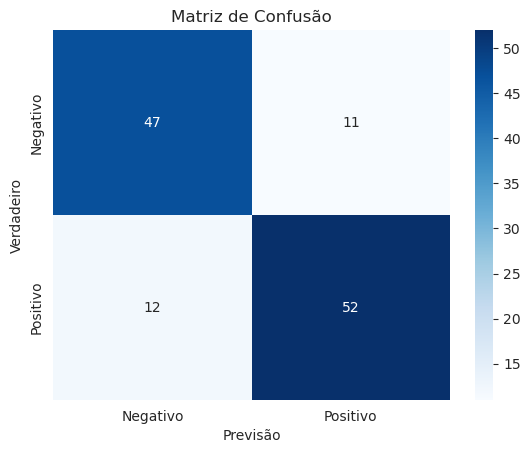

In [33]:
# Visualização a matriz de confusão
cm = confusion_matrix(y_teste, y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = ['Negativo', 'Positivo'],
            yticklabels = ['Negativo', 'Positivo'])
plt.xlabel('Previsão')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()

**1. Acurácia (Accuracy)**

De todos os reviews (positivos e negativos) que o modelo analisou, qual a porcentagem totoal de acertos?

Em nosso contexto: Se você passou 100 reviews e ele acertou a classificação de 92 deles (independentemente de serem positivos ou negativos), a acurácia é de 92%. É a média mais geral de performance.

**2. Precisão (Precision)**

Esta métrica é calculada para cada classe.

Precisão para a classe 'Positivo': Dos reviews que o modelo rotulou como 'Positivos', quantos eram realmente positivos?

Em nosso contexto: Se o modelo marcou 10 reviews como 'positivos', mas apenas 9 deles eram de fato positivos ( e 1 erra um erro, um falso positivo), a precisão para a classe 'Positivo' é de 90%.

Importância: Uma alta precisão aqui significa que você pode confiar na etiqueta 'positivo'. Se você for usar esses reviews em um material de marketing, por exemplo, não quer mostrar acidentalmente um review negativo.

Precisão para a classe 'Negativo': Dos reviews que o modelo rotulou como 'Negativos', quantos eram realmente negativos?

Em nosso contexto: Se o modelo marcou 10 reviews como 'Negativos' e todos os 10 foram de fato negativos, a precisão para a classe 'Negativa' é de 100%.

Importância: Essencial para a equipe de suporte. Uma alta precisão garante que o tempo da equipe não seja gasto analisando reviews que na verdade eram positivos (falsos negativos para o time de suporte)

**3. Recall**

Esta métrica também é calculada para cada classe.

Recall para a classe 'Pasitivo': De todos os reviews que eram Positivos, quantos o modelo conseguiu encontrar?

Em nosso contexto: Se existem 12 reviews positivos no total, mas o modelo só conseguiu identificar 9 deles (deixando 3 passarem dispercebidos), o recall para a classe 'Positivo' é de 75% (9 de 12).

Importância: Um alto recall aqui garante que você está capturando a maior parte do feedback positivo.Não estamos perdendo a oportunidadee de identificar clientes satisfeitos.

Recall para a classe 'Negativo': De todos os reviews que realmente eram Negativos, quantos o modelo conseguiu encontrar?

Em nosso contexto: Se existem 10 clientes insatisfeitos (reviews negativos), e o modelo identificou nove deles, o recall para 'Negativo' é de 90%. Ele "deixou escapar" um cliente insatisfeito.

Importância: Talvez a métrica mais crítica para a gestão de crises. Um alto recall para 'Negativo' é vital para garantir que quase nenhuma reclamação passe despercebida e que a equipe de suporte possa agir.

**4. F1-Score**

Qual é o balanço equilibrado entre a Precisão e o Recall para cada classe?

Em nosso contexto: É uma única nota que combina as duas métricas anteriores. O F1-Score para a classe 'Positivo' só será alto se tanto a precisão quanto o recall para 'Positivo' forem altos. Ele evita o cenário onde um modelo é ótimo em uma métrica, mas péssimo em outra. É frequêntemente a melhor métrica para avaliar a performance do modelo em uma classe específica.

**5. Support (Suporte)**

Quantos reviews de cada classe realmente existem no meu conjunto de teste?

Em nosso contexto: Se o relatório mostra um support de 58 para 'Positivo' e 62 para 'Negativo', significa que no seu conjunto de dados de teste havia 58 reviews positivos e 62 negativos.

Importância: Dá contexto aos resultados. Se o support de uma classe for muito baixo, as métricas de performance para essa classe são menos confiáveis, pois foram calculadas com base em poucos exemplos.

In [34]:
# Se satisfeitos com a performance do modelo, salvamos em disco
joblib.dump(melhor_modelo, 'modelo_sentimento_v1.joblib')

['modelo_sentimento_v1.joblib']

In [35]:
# Deletando o modelo treinado e removendo da memória
# del melhor_modelo

**Nota: Normalmente aqui termina o trabalho de um *Cientista de Dados*. A etapa a seguir é, normalmente, responsabilidade de um *Engenheiro de Machine Learning*.**

**10. MLOps, Deploy e Uso no Modelo**

Etapa final, onde o modelo começa a gerar valor. "Deploy" significa colocar o modelo treinado em produção. No nosso caso, simulamos isso criando a função prever_sentimento, que encapsula o pipeline e pode ser usada para classificar novos reviews de forma rápida e automática.

In [36]:
# Carregar o modelo a partir do disco
modelo_deploy = joblib.load('modelo_sentimento_v1.joblib')

In [37]:
type(modelo_deploy)

sklearn.pipeline.Pipeline

In [38]:
# Criar novos dados para simular o uso em produção
novos_reviews = [
    "A bateria do celular não dura nada, péssima compra.",
    "Chegou antes do prazo e o produto é de ótima qualidade! Estou muito feliz.",
    "O serviço de atendimento foi rápido e eficiente.",
    "Não recomendo, veio faltando peça e a cor estava errada."
]

In [39]:
# Função para prever o sentimento de novos reviews
def prever_sentimento(reviews):

    """
    Recebe uma lista de texto de reviews e retorna a previsão de sentimentos.
    O objetivo 'melhor_modelo' (pipeline) cuida de todos os passos internos.
    """

    # 1. 'reviews' entra no pipeline
    # 2. TF-IDF é aplicado internamente
    # 3. StandardScaler é aplicado internamente
    # 4. LogisticRegression faz a previsão
    previsoes = modelo_deploy.predict(reviews)

    # Mapeia o resultado númerico de volta para texto
    sentimentos = ['Negativo' if p == 0 else 'Positivo' for p in previsoes]

    # Exibe os resultados
    for review, sentimento in zip(reviews, sentimentos):
        print(f"\nReview: '{review}'\nSentimento Previsto: {sentimento}\n---")

In [40]:
# Executando a função de deploy com os novos dados
print("\n--- Iniciando Classificação de Novos Reviews (Deploy com Pipeline Completo) ---\n")
prever_sentimento(novos_reviews)


--- Iniciando Classificação de Novos Reviews (Deploy com Pipeline Completo) ---


Review: 'A bateria do celular não dura nada, péssima compra.'
Sentimento Previsto: Negativo
---

Review: 'Chegou antes do prazo e o produto é de ótima qualidade! Estou muito feliz.'
Sentimento Previsto: Positivo
---

Review: 'O serviço de atendimento foi rápido e eficiente.'
Sentimento Previsto: Negativo
---

Review: 'Não recomendo, veio faltando peça e a cor estava errada.'
Sentimento Previsto: Negativo
---


**Fim do projeto**